# 05 — Transformery: HerBERT vs XLM-RoBERTa

Fine-tuning multi-label na 8 emocjach (TwitterEmo):
- `allegro/herbert-base-cased` (~110M), pełny FT
- `FacebookAI/xlm-roberta-base` (~270M), pełny FT
- `allegro/herbert-large-cased` (~340M), **LoRA** (mieści się na ~6 GB)

8 wyjść sigmoid, BCEWithLogitsLoss, progi na val, test z bootstrap 95% CI.

> Przy ~6 GB VRAM: `batch_size=16`, `fp16`, `max_length=128`. Przy OOM zejść do 8 i/lub `gradient_accumulation_steps=2`.

## 1. Setup

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.special import expit
from sklearn.metrics import (
    f1_score, hamming_loss, jaccard_score, accuracy_score, precision_score, recall_score,
)
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
import mlflow

from thesis_lib import evaluate, optimal_thresholds, bootstrap_f1_ci as f1_macro_ci
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["savefig.dpi"] = 300

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EMOTIONS = ["radość", "smutek", "zaufanie", "wstręt", "strach", "gniew", "przeczuwanie", "zdziwienie"]
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR   = Path("../data/results")
FIGURES_DIR   = Path("../figures")
HF_OUT        = Path("../data/transformers")   # training artifacts (gitignored)
for d in [RESULTS_DIR, FIGURES_DIR, HF_OUT]:
    d.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}, torch={torch.__version__}")

In [2]:
# --- Load data ---
tw_train = pd.read_csv(PROCESSED_DIR / "twitteremo_train.csv").reset_index(drop=True)
tw_val   = pd.read_csv(PROCESSED_DIR / "twitteremo_val.csv").reset_index(drop=True)
tw_test  = pd.read_csv(PROCESSED_DIR / "twitteremo_test.csv").reset_index(drop=True)
for df in (tw_train, tw_val, tw_test):
    df["tekst"] = df["tekst"].fillna("")

y_tw_val  = tw_val[EMOTIONS].values
y_tw_test = tw_test[EMOTIONS].values
print(f"train={len(tw_train):,}  val={len(tw_val):,}  test={len(tw_test):,}")

train=28,684  val=5,737  test=1,435


## 2. Metryki, progi, bootstrap CI (te same co w 03)

In [ ]:
#   evaluate, bootstrap_f1_ci as f1_macro_ci).
# (3. arg `labels` ignorowany; siatka 0.05–0.95/0.01 = oryginał).
def find_optimal_thresholds(y_true, y_proba, labels=None):
    return optimal_thresholds(y_true, y_proba)

## 3. MLflow

In [4]:
# Newer MLflow refuses the file-store backend unless explicitly opted in.
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

MLFLOW_DIR = Path("../mlruns").resolve()
mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment("transformers_thesis")
print(f"MLflow -> {MLFLOW_DIR} (eksperyment: transformers_thesis)")

MLflow -> /path/to/repo/mlruns (eksperyment: transformers_thesis)


## 4. Fine-tuning — wspólny pipeline

Jedna funkcja `train_transformer(model_name)` dla obu modeli: trening → sigmoid → progi per emocja na val → test + CI.

In [5]:
import torch.nn.functional as F
from transformers import EarlyStoppingCallback

# --- pos_weight: odwrotna częstość klas (capped) -> waży rzadkie emocje w stracie BCE ---
_pos = tw_train[EMOTIONS].values.sum(axis=0)
_neg = len(tw_train) - _pos
POS_WEIGHT = torch.tensor(np.clip(_neg / np.maximum(_pos, 1), 1.0, 10.0), dtype=torch.float32)
print("pos_weight:", {e: round(w, 2) for e, w in zip(EMOTIONS, POS_WEIGHT.tolist())})


class WeightedTrainer(Trainer):
    """Trainer z ważoną BCE (pos_weight) zamiast gołej BCEWithLogitsLoss."""
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = F.binary_cross_entropy_with_logits(
            logits, labels.float(),
            pos_weight=self.pos_weight.to(logits.device) if self.pos_weight is not None else None,
        )
        return (loss, outputs) if return_outputs else loss


def train_transformer(model_name, epochs=8, batch_size=8, lr=2e-5, max_len=128,
                      use_lora=False, lora_lr=1e-4, lora_r=16, lora_alpha=32,
                      weighted=True, patience=2):
    short = model_name.split("/")[-1]
    label = short + ("-lora" if use_lora else "")
    print(f"\n=== Fine-tuning {label} (weighted={weighted}, epochs<= {epochs}, early stop) ===")
    tok = AutoTokenizer.from_pretrained(model_name)

    def to_ds(df):
        d = Dataset.from_dict({
            "text": df["tekst"].tolist(),
            "labels": df[EMOTIONS].values.astype("float32").tolist(),
        })
        return d.map(lambda b: tok(b["text"], truncation=True, max_length=max_len),
                     batched=True, remove_columns=["text"])

    ds_train, ds_val, ds_test = to_ds(tw_train), to_ds(tw_val), to_ds(tw_test)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(EMOTIONS), problem_type="multi_label_classification",
    )

    if use_lora:
        from peft import LoraConfig, get_peft_model, TaskType
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS, r=lora_r, lora_alpha=lora_alpha,
            lora_dropout=0.1, target_modules=["query", "value"],
        )
        model = get_peft_model(model, lora_cfg)
        model.enable_input_require_grads()      # wymagane razem z gradient_checkpointing
        model.print_trainable_parameters()
        lr = lora_lr                            # LoRA -> wyzszy LR niz pelny fine-tune

    args = TrainingArguments(
        output_dir=str(HF_OUT / label),
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,          # efektywny batch = batch_size*2
        gradient_checkpointing=True,            # mniej VRAM kosztem szybkosci (pod ~6 GB GPU)
        num_train_epochs=epochs, learning_rate=lr, warmup_ratio=0.1, weight_decay=0.01,
        fp16=torch.cuda.is_available(), logging_steps=50, report_to="none", seed=RANDOM_STATE,
    )

    def compute_metrics(p):
        probs = expit(p.predictions)
        pred = (probs >= 0.5).astype(int)
        return {"f1_macro": f1_score(p.label_ids.astype(int), pred, average="macro", zero_division=0)}

    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
        data_collator=DataCollatorWithPadding(tok), compute_metrics=compute_metrics,
        pos_weight=POS_WEIGHT if weighted else None,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )
    trainer.train()

    p_val  = expit(trainer.predict(ds_val).predictions)
    p_test = expit(trainer.predict(ds_test).predictions)

    thr = find_optimal_thresholds(y_tw_val, p_val, EMOTIONS)
    pred_test = (p_test >= thr).astype(int)
    m = evaluate(y_tw_test, pred_test)
    _, lo, hi = f1_macro_ci(y_tw_test, pred_test)
    m.update({"model": label, "ci_low": round(lo, 3), "ci_high": round(hi, 3)})

    with mlflow.start_run(run_name=f"transformer:{label}"):
        mlflow.set_tag("phase", "transformer")
        mlflow.set_tag("model", label)
        mlflow.set_tag("lora", str(use_lora))
        mlflow.set_tag("weighted", str(weighted))
        mlflow.set_tag("dataset", "twitteremo")
        mlflow.set_tag("split", "test")
        mlflow.log_params({"model_name": model_name, "epochs": epochs,
                           "batch_size": batch_size, "lr": lr, "max_len": max_len,
                           "use_lora": use_lora, "weighted": weighted})
        mlflow.log_metrics({k: float(v) for k, v in m.items() if isinstance(v, (int, float))})

    print(f"  {label}: F1-Macro={m['f1_macro']:.3f}  [{lo:.3f}, {hi:.3f}]")
    del trainer, model
    torch.cuda.empty_cache()
    return m, p_test, pred_test

pos_weight: {'radość': 7.72, 'smutek': 10.0, 'zaufanie': 10.0, 'wstręt': 3.31, 'strach': 10.0, 'gniew': 4.66, 'przeczuwanie': 1.85, 'zdziwienie': 10.0}


## 5. Trening HerBERT + XLM-RoBERTa

In [6]:
RUNS = [
    {"model": "allegro/herbert-base-cased",   "use_lora": False},  # PL base, pelny fine-tune
    {"model": "FacebookAI/xlm-roberta-base",  "use_lora": False},  # multilingual base, pelny fine-tune
    {"model": "allegro/herbert-large-cased",  "use_lora": True},   # PL large, LoRA (mniej VRAM)
]

transformer_results = {}
for cfg in RUNS:
    m, p_test, pred_test = train_transformer(cfg["model"], use_lora=cfg["use_lora"])
    transformer_results[m["model"]] = m

tr_df = pd.DataFrame(list(transformer_results.values()))
tr_df.to_csv(RESULTS_DIR / "transformers_results.csv", index=False)
display(tr_df[["model", "f1_macro", "ci_low", "ci_high", "f1_micro", "jaccard_macro", "hamming_loss"]])


=== Fine-tuning herbert-base-cased (weighted=True, epochs<= 8, early stop) ===


Map:   0%|          | 0/28684 [00:00<?, ? examples/s]

Map:   7%|▋         | 2000/28684 [00:00<00:02, 12060.95 examples/s]

Map:  14%|█▍        | 4000/28684 [00:00<00:02, 11889.88 examples/s]

Map:  21%|██        | 6000/28684 [00:00<00:01, 11967.88 examples/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,581,064 || all params: 356,678,672 || trainable%: 0.4433


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.140883,0.566023,0.460861
2,1.077191,0.509783,0.517835
3,1.059572,0.501451,0.504989
4,1.030437,0.495634,0.524896
5,0.960380,0.494277,0.528191
6,0.793020,0.494699,0.554020
7,0.924731,0.491347,0.547876
8,0.836909,0.492699,0.549500


  herbert-large-cased-lora: F1-Macro=0.563  [0.513, 0.606]


,model,f1_macro,ci_low,ci_high,f1_micro,jaccard_macro,hamming_loss
0,herbert-base-cased,0.551348,0.510,0.588,0.643413,0.392075,0.099739
1,xlm-roberta-base,0.539815,0.501,0.576,0.634483,0.380545,0.106185
2,herbert-large-cased-lora,0.562844,0.513,0.606,0.652229,0.401606,0.095122


## 6. Porównanie: klasyczne vs transformery

Porównanie F1-Macro na teście (z 95% CI):


,system,f1_macro,ci95
0,"Klasyczny (najlepszy, 03c)",0.474000,"[0.436, 0.510]"
1,herbert-base-cased,0.551348,"[0.510, 0.588]"
2,xlm-roberta-base,0.539815,"[0.501, 0.576]"
3,herbert-large-cased-lora,0.562844,"[0.513, 0.606]"


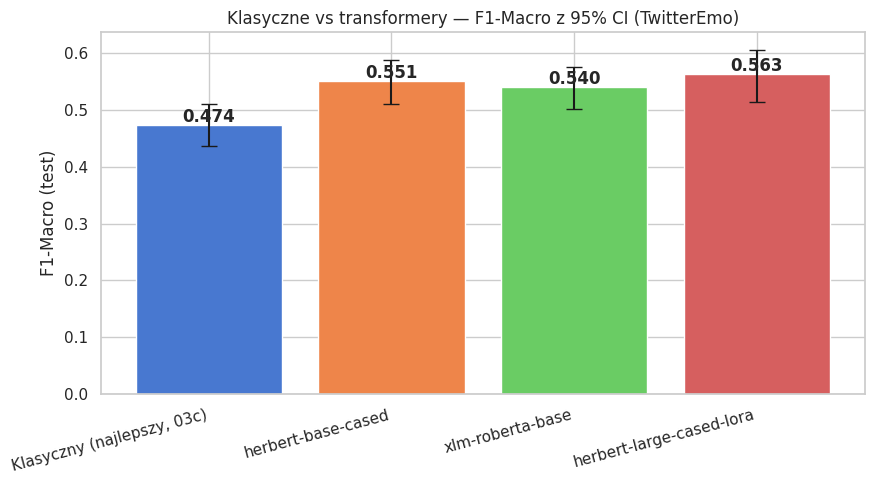

In [7]:
# Best classical = wynik FINAL z 03c (z 95% CI)
classical = pd.read_csv(RESULTS_DIR / "final_test_ci.csv")
best_classical = classical.iloc[classical["f1_macro"].idxmax()]

rows = [{"system": "Klasyczny (najlepszy, 03c)", "f1_macro": best_classical["f1_macro"],
         "ci_low": best_classical["ci_low"], "ci_high": best_classical["ci_high"]}]
for _, r in tr_df.iterrows():
    rows.append({"system": r["model"], "f1_macro": r["f1_macro"],
                 "ci_low": r["ci_low"], "ci_high": r["ci_high"]})
cmp_df = pd.DataFrame(rows)
cmp_df["ci95"] = cmp_df.apply(lambda x: f"[{x['ci_low']:.3f}, {x['ci_high']:.3f}]", axis=1)
cmp_df.to_csv(RESULTS_DIR / "classical_vs_transformers.csv", index=False)
print("Porównanie F1-Macro na teście (z 95% CI):")
display(cmp_df[["system", "f1_macro", "ci95"]])

# Wykres z przedzialami ufnosci (blad = polowa szerokosci CI)
fig, ax = plt.subplots(figsize=(9, 5))
yerr = [cmp_df["f1_macro"] - cmp_df["ci_low"], cmp_df["ci_high"] - cmp_df["f1_macro"]]
ax.bar(cmp_df["system"], cmp_df["f1_macro"], yerr=yerr, capsize=6,
       color=sns.color_palette("muted", len(cmp_df)))
ax.set_ylabel("F1-Macro (test)")
ax.set_title("Klasyczne vs transformery — F1-Macro z 95% CI (TwitterEmo)")
plt.xticks(rotation=15, ha="right")
for i, r in cmp_df.iterrows():
    ax.text(i, r["f1_macro"] + 0.005, f"{r['f1_macro']:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classical_vs_transformers.pdf", bbox_inches="tight")
plt.show()